# Marketing Mix Model (MMM) — HAMS Data Science Challenge

**Author:** Muhammad Humza ( github: humzajameel )  
**Date:** 07 May 2026

## Objective
Build a Bayesian Marketing Mix Model using PyMC to quantify the 
contribution of 7 marketing channels to weekly revenue, 
and estimate ROI per channel.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
from sklearn.metrics import mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('MMM_test_data.csv')
df['start_of_week'] = pd.to_datetime(df['start_of_week'], format='%d-%m-%y')
df = df.sort_values('start_of_week').reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df['start_of_week'].min(), "→", df['start_of_week'].max())
df.head()

Shape: (104, 9)
Date range: 2020-08-30 00:00:00 → 2022-08-21 00:00:00


,start_of_week,revenue,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7
0,2020-08-30,157906.75,2625.48,262.71,12954.12,3609.63,12955.29,12659.12,19379.79
1,2020-09-06,186425.68,2634.01,108.66,8760.28,4560.60,12747.70,12338.18,22473.45
2,2020-09-13,161607.39,2087.08,110.32,7155.42,4362.96,15015.41,10811.15,22596.05
3,2020-09-20,180089.13,1690.70,52.79,15185.22,3883.41,15521.41,12890.22,24728.73
4,2020-09-27,217793.98,1547.30,80.56,18524.05,4043.09,15793.74,12642.55,26515.48


## 1. Exploratory Data Analysis (EDA) & Data Validation
Before any modeling, we interrogate the data for quality issues.

In [3]:
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Null Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print("Duplicates:", df.duplicated().sum())

print("\n=== Negative Values Check ===")
spend_cols = [f'spend_channel_{i}' for i in range(1, 8)]
print((df[spend_cols] < 0).sum())

print("\n=== Missing Weeks Check ===")
expected_weeks = pd.date_range(df['start_of_week'].min(), df['start_of_week'].max(), freq='W-SUN')
missing = set(expected_weeks) - set(df['start_of_week'])
print("Missing weeks:", len(missing))

=== Shape ===
(104, 9)

=== Data Types ===
start_of_week      datetime64[us]
revenue                   float64
spend_channel_1           float64
spend_channel_2           float64
spend_channel_3           float64
spend_channel_4           float64
spend_channel_5           float64
spend_channel_6           float64
spend_channel_7           float64
dtype: object

=== Null Values ===
start_of_week      0
revenue            0
spend_channel_1    0
spend_channel_2    0
spend_channel_3    0
spend_channel_4    0
spend_channel_5    0
spend_channel_6    0
spend_channel_7    0
dtype: int64

=== Duplicate Rows ===
Duplicates: 0

=== Negative Values Check ===
spend_channel_1    0
spend_channel_2    0
spend_channel_3    0
spend_channel_4    0
spend_channel_5    0
spend_channel_6    0
spend_channel_7    0
dtype: int64

=== Missing Weeks Check ===
Missing weeks: 0


In [4]:
df.describe().round(2)

,start_of_week,revenue,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7
count,104,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00
mean,2021-08-25 12:00:00,136490.19,1245.60,343.64,19507.18,6915.14,8575.61,5063.70,27701.37
min,2020-08-30 00:00:00,63207.09,0.00,4.37,5938.13,3602.20,747.46,0.00,9391.21
25%,2021-02-26 06:00:00,101675.68,334.28,120.47,13879.00,5113.94,2902.03,0.00,19797.71
50%,2021-08-25 12:00:00,128790.46,856.87,202.02,17929.45,6194.40,6879.27,2423.10,24248.64
75%,2022-02-21 18:00:00,157707.28,1658.03,553.08,22252.26,7470.56,14367.58,8701.96,33852.65
max,2022-08-21 00:00:00,418186.38,8513.83,1605.85,49689.38,22629.69,33009.65,33692.83,77488.42
std,NaN,50810.25,1388.38,332.99,8714.76,3123.17,6956.79,6689.47,12176.29


### Revenue & Spend Over Time

plt.figure(figsize=(14, 4))
plt.plot(df['start_of_week'], df['revenue'], color='steelblue', linewidth=2)
plt.title('Weekly Revenue Over Time')
plt.xlabel('Week')
plt.ylabel('Revenue (€)')
plt.tight_layout()
plt.show()

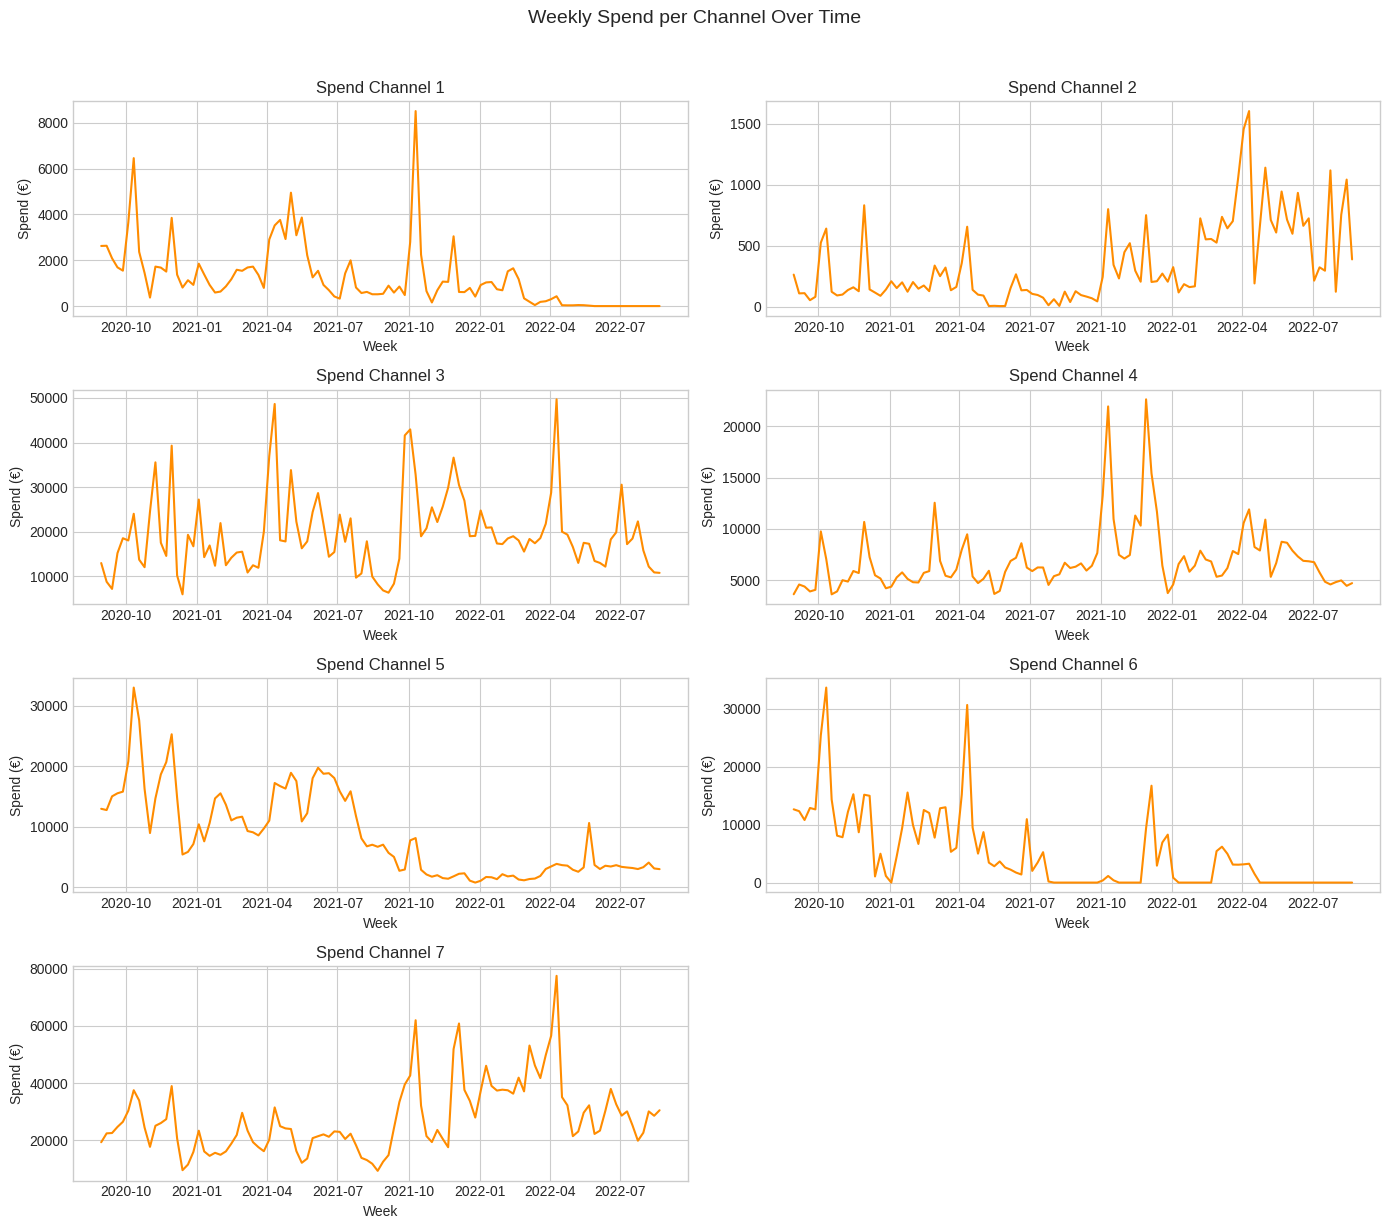

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(spend_cols):
    axes[i].plot(df['start_of_week'], df[col], color='darkorange', linewidth=1.5)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Week')
    axes[i].set_ylabel('Spend (€)')

axes[-1].set_visible(False)
plt.suptitle('Weekly Spend per Channel Over Time', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Correlation: Spend vs Revenue

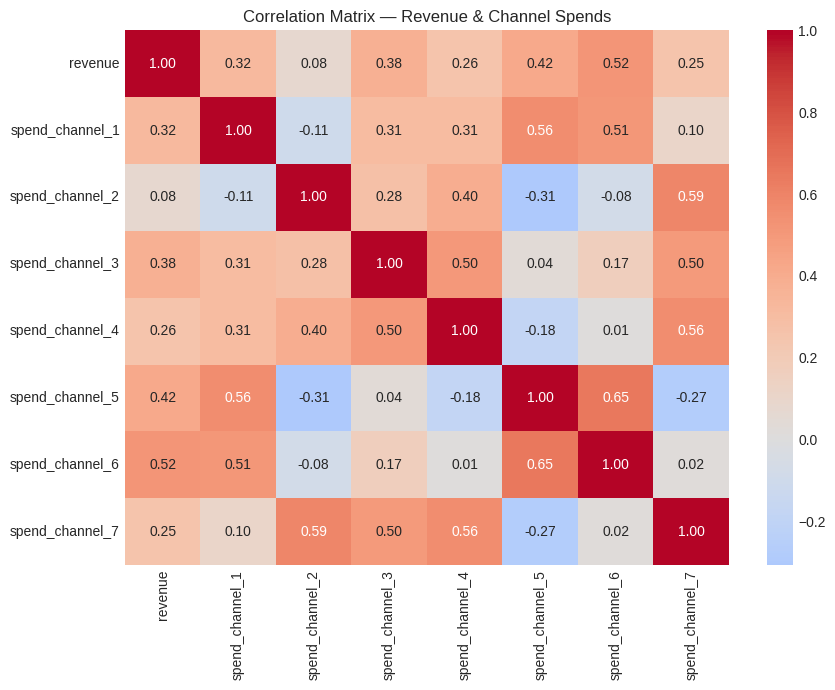

In [6]:
corr = df[['revenue'] + spend_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Revenue & Channel Spends')
plt.tight_layout()
plt.show()

## 2. Adstock Transformation
Ads have a delayed effect — this week's spend influences future weeks.
We model this carry-over effect using adstock transformation.
A decay rate close to 1 = long memory, close to 0 = short memory.

In [7]:
def adstock(x, decay):
    result = np.zeros_like(x, dtype=float)
    result[0] = x[0]
    for t in range(1, len(x)):
        result[t] = x[t] + decay * result[t-1]
    return result

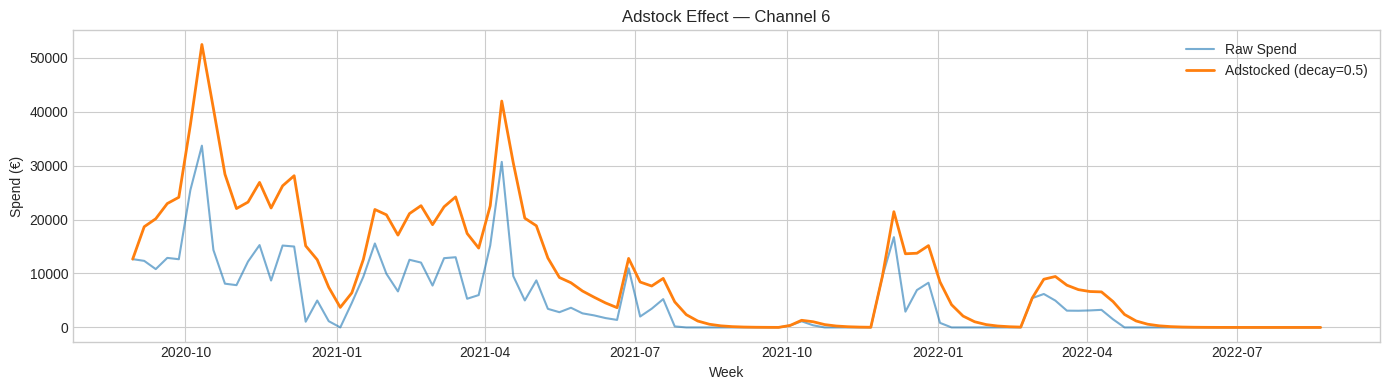

In [8]:
decay_rate = 0.5
channel = df['spend_channel_6'].values

plt.figure(figsize=(14, 4))
plt.plot(df['start_of_week'], channel, label='Raw Spend', alpha=0.6)
plt.plot(df['start_of_week'], adstock(channel, decay_rate), 
         label=f'Adstocked (decay={decay_rate})', linewidth=2)
plt.title('Adstock Effect — Channel 6')
plt.xlabel('Week')
plt.ylabel('Spend (€)')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# We will let the model LEARN the decay rates
# For now apply a fixed 0.5 as starting point for visualization only
decay_fixed = 0.5
spend_cols = [f'spend_channel_{i}' for i in range(1, 8)]

adstocked_data = np.column_stack([
    adstock(df[col].values, decay_fixed) for col in spend_cols
])

print("Adstocked spend matrix shape:", adstocked_data.shape)

Adstocked spend matrix shape: (104, 7)


## 3. Seasonality & Trend Features
Revenue shows a clear yearly seasonality and downward trend.
We capture this using Fourier terms (sine/cosine waves) for seasonality
and a simple time index for trend.

In [10]:
# Trend — simple normalized index 0 to 1
df['trend'] = np.arange(len(df)) / len(df)

# Seasonality — Fourier terms (captures yearly cycles)
# One pair of sin/cos = one frequency = one "wave" per year
period = 52  # 52 weeks in a year

df['sin_1'] = np.sin(2 * np.pi * 1 * np.arange(len(df)) / period)
df['cos_1'] = np.cos(2 * np.pi * 1 * np.arange(len(df)) / period)
df['sin_2'] = np.sin(2 * np.pi * 2 * np.arange(len(df)) / period)
df['cos_2'] = np.cos(2 * np.pi * 2 * np.arange(len(df)) / period)

print("New features added:", ['trend', 'sin_1', 'cos_1', 'sin_2', 'cos_2'])
df[['start_of_week', 'trend', 'sin_1', 'cos_1']].head()

New features added: ['trend', 'sin_1', 'cos_1', 'sin_2', 'cos_2']


,start_of_week,trend,sin_1,cos_1
0,2020-08-30,0.000000,0.000000,1.000000
1,2020-09-06,0.009615,0.120537,0.992709
2,2020-09-13,0.019231,0.239316,0.970942
3,2020-09-20,0.028846,0.354605,0.935016
4,2020-09-27,0.038462,0.464723,0.885456


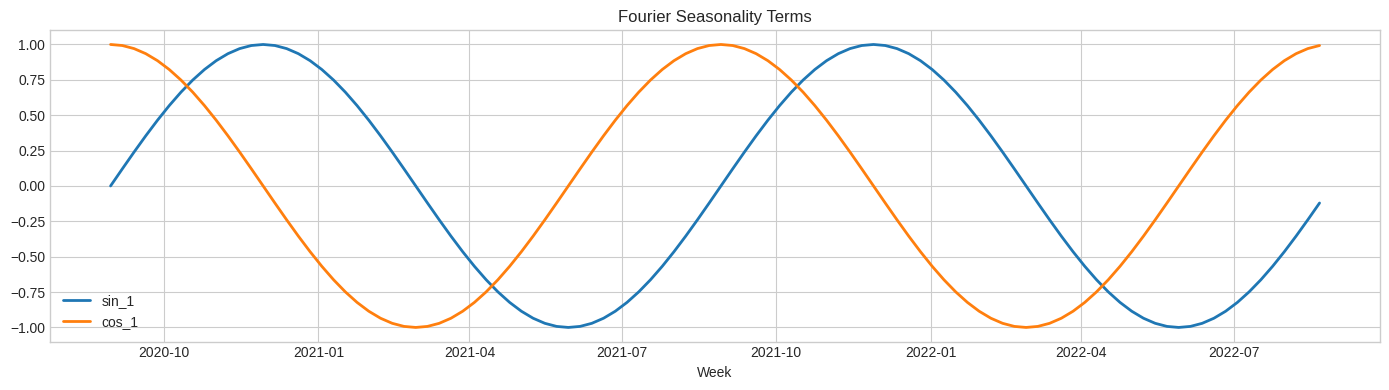

In [11]:
plt.figure(figsize=(14, 4))
plt.plot(df['start_of_week'], df['sin_1'], label='sin_1', linewidth=2)
plt.plot(df['start_of_week'], df['cos_1'], label='cos_1', linewidth=2)
plt.title('Fourier Seasonality Terms')
plt.xlabel('Week')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Bayesian MMM Model (PyMC)

### How the model thinks about revenue:
revenue = intercept + trend + seasonality + sum(channel contributions) + noise

### Key design decisions:
- Adstock decay rates are LEARNED by the model (not hardcoded)
- Channel betas are HalfNormal (positive only — spend can't hurt revenue)
- Priors are weakly informative — we guide but don't force the model

In [12]:
# Normalize revenue and spend to help sampler
revenue_mean = df['revenue'].mean()
revenue_std = df['revenue'].std()
revenue_scaled = (df['revenue'].values - revenue_mean) / revenue_std

spend_raw = np.column_stack([df[col].values for col in spend_cols])
spend_means = spend_raw.mean(axis=0)
spend_stds = spend_raw.std(axis=0)
spend_scaled = (spend_raw - spend_means) / spend_stds

n_channels = len(spend_cols)
n_obs = len(df)

print("Revenue scaled — mean:", revenue_scaled.mean().round(4), "std:", revenue_scaled.std().round(4))
print("Spend scaled shape:", spend_scaled.shape)

Revenue scaled — mean: -0.0 std: 0.9952
Spend scaled shape: (104, 7)


In [13]:
with pm.Model() as mmm:

    # --- Adstock decay priors (one per channel) ---
    # Beta distribution: constrained between 0 and 1
    # mean ~0.5 means we expect moderate carry-over
    decay = pm.Beta('decay', alpha=3, beta=3, shape=n_channels)

    # --- Apply adstock inside model ---
    adstocked_channels = pm.Deterministic(
        'adstocked_channels',
        pm.math.stack([
            pm.math.concatenate([[spend_scaled[0, i]], [
                spend_scaled[t, i] + decay[i] * spend_scaled[t-1, i]
                for t in range(1, n_obs)
            ]])
            for i in range(n_channels)
        ], axis=1)
    )

    # --- Channel contribution betas ---
    # HalfNormal: positive only (spend should help revenue)
    betas = pm.HalfNormal('betas', sigma=1, shape=n_channels)

    # --- Trend ---
    trend_coef = pm.Normal('trend_coef', mu=0, sigma=1)

    # --- Seasonality ---
    sin1_coef = pm.Normal('sin1_coef', mu=0, sigma=1)
    cos1_coef = pm.Normal('cos1_coef', mu=0, sigma=1)
    sin2_coef = pm.Normal('sin2_coef', mu=0, sigma=1)
    cos2_coef = pm.Normal('cos2_coef', mu=0, sigma=1)

    # --- Intercept ---
    intercept = pm.Normal('intercept', mu=0, sigma=2)

    # --- Expected revenue ---
    seasonality = (sin1_coef * df['sin_1'].values +
                   cos1_coef * df['cos_1'].values +
                   sin2_coef * df['sin_2'].values +
                   cos2_coef * df['cos_2'].values)

    mu = (intercept +
          trend_coef * df['trend'].values +
          seasonality +
          pm.math.dot(adstocked_channels, betas))

    # --- Noise ---
    sigma = pm.HalfNormal('sigma', sigma=1)

    # --- Likelihood ---
    revenue_obs = pm.Normal('revenue_obs', mu=mu, sigma=sigma, observed=revenue_scaled)

In [14]:
with mmm:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42
    )

print("Sampling complete!")

 Progress                      Draw   Divergences   Step size   Grad evals   Speed           Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.116       15           48.72 draws/s   0:00:41   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.175       31           50.35 draws/s   0:00:39   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.160       15           51.19 draws/s   0:00:39   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.168       31           50.49 draws/s   0:00:39   0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 41 seconds.


Sampling complete!


## 5. Model Diagnostics — Did the model converge?
R-hat close to 1.0 = chains agreed = good convergence.
ESS (Effective Sample Size) should be > 100 per chain.

In [15]:
summary = az.summary(trace, var_names=['betas', 'decay', 'trend_coef', 
                                        'sin1_coef', 'cos1_coef', 'intercept', 'sigma'])
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.027,0.028,0.000,0.077,0.000,0.001,4146.0,1939.0,1.00
betas[1],0.124,0.075,0.000,0.251,0.001,0.001,2504.0,1717.0,1.00
betas[2],0.145,0.078,0.004,0.283,0.001,0.001,2558.0,1600.0,1.00
betas[3],0.063,0.052,0.000,0.160,0.001,0.001,3073.0,1615.0,1.00
betas[4],0.247,0.113,0.020,0.441,0.002,0.002,2382.0,1868.0,1.00
betas[5],0.096,0.068,0.000,0.217,0.001,0.001,2974.0,1982.0,1.00
betas[6],0.095,0.067,0.000,0.212,0.001,0.001,2515.0,2221.0,1.00
decay[0],0.477,0.197,0.129,0.833,0.003,0.003,4767.0,2374.0,1.01
decay[1],0.433,0.187,0.110,0.777,0.003,0.002,4831.0,3039.0,1.00
decay[2],0.400,0.185,0.082,0.744,0.003,0.003,4922.0,2993.0,1.00


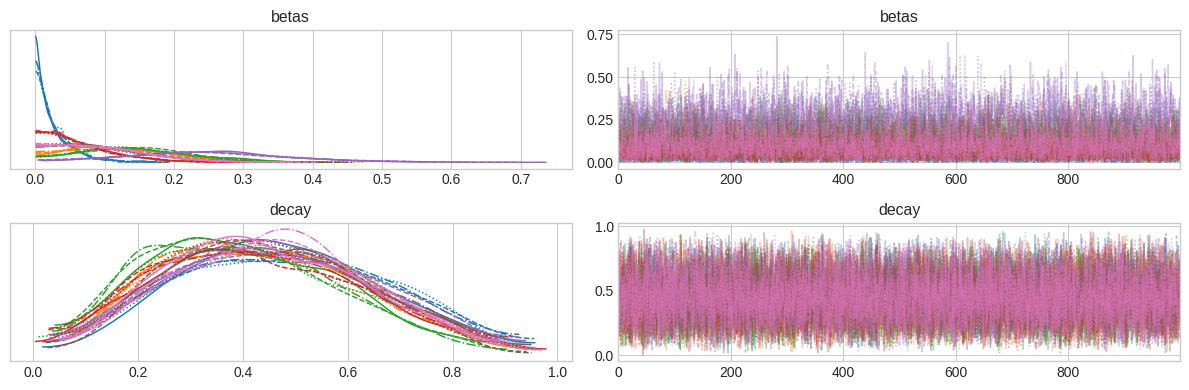

In [16]:
az.plot_trace(trace, var_names=['betas', 'decay'], compact=True)
plt.tight_layout()
plt.show()

## 6. Model Evaluation — How well does it fit?

In [17]:
with mmm:
    ppc = pm.sample_posterior_predictive(trace, random_seed=42)

print("Posterior predictive sampling complete!")

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:00

Posterior predictive sampling complete!


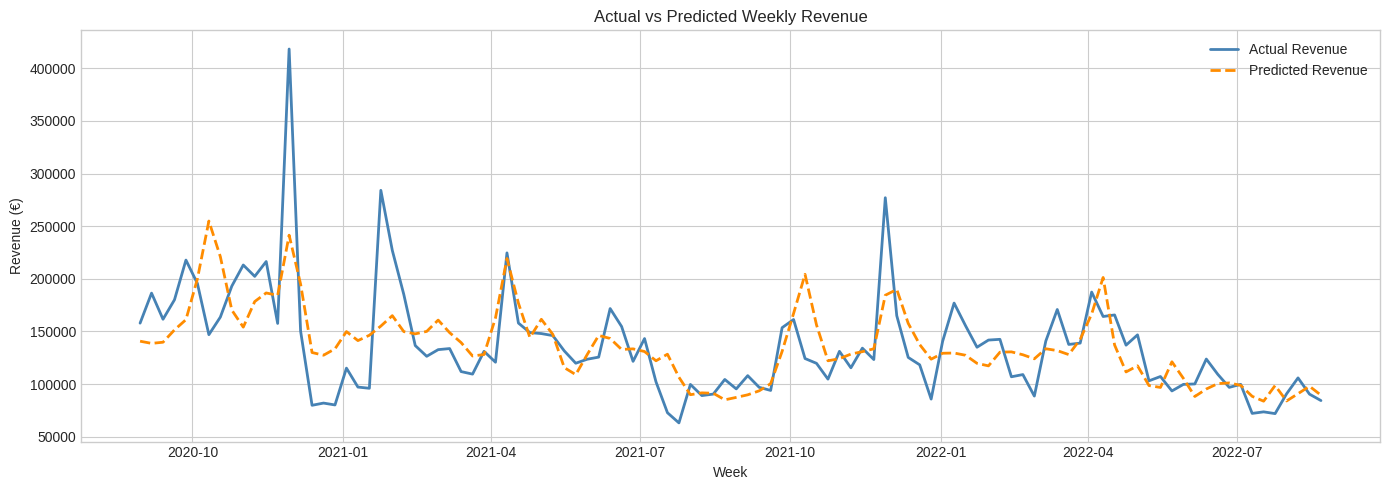

In [18]:
# Extract predicted values and rescale back to original
predicted_scaled = ppc.posterior_predictive['revenue_obs'].mean(dim=['chain', 'draw']).values
predicted = predicted_scaled * revenue_std + revenue_mean
actual = df['revenue'].values

plt.figure(figsize=(14, 5))
plt.plot(df['start_of_week'], actual, label='Actual Revenue', linewidth=2, color='steelblue')
plt.plot(df['start_of_week'], predicted, label='Predicted Revenue', linewidth=2, 
         color='darkorange', linestyle='--')
plt.title('Actual vs Predicted Weekly Revenue')
plt.xlabel('Week')
plt.ylabel('Revenue (€)')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
mape = mean_absolute_percentage_error(actual, predicted)
print(f"MAPE: {mape*100:.2f}%")
print(f"Mean Absolute Error: €{np.abs(actual - predicted).mean():,.0f}")
print(f"R² (approx): {1 - np.var(actual - predicted) / np.var(actual):.3f}")

MAPE: 19.63%
Mean Absolute Error: €26,577
R² (approx): 0.449


## 7. Channel ROI Analysis
ROI = Revenue attributed to channel / Money spent on channel
A ROI > 1 means the channel generates more revenue than it costs.

In [20]:
betas_mean = trace.posterior['betas'].mean(dim=['chain', 'draw']).values
decay_mean = trace.posterior['decay'].mean(dim=['chain', 'draw']).values

roi_data = []
for i, col in enumerate(spend_cols):
    # Apply adstock with learned decay
    adstocked = adstock(df[col].values, decay_mean[i])
    
    # Revenue attributed = beta * adstocked spend (rescaled back)
    attributed_scaled = betas_mean[i] * (adstocked - spend_means[i]) / spend_stds[i]
    attributed_revenue = attributed_scaled * revenue_std
    
    total_spend = df[col].sum()
    total_attributed = attributed_revenue.sum()
    roi = total_attributed / total_spend if total_spend > 0 else 0
    
    roi_data.append({
        'channel': col.replace('spend_', '').replace('_', ' ').title(),
        'total_spend': total_spend,
        'attributed_revenue': total_attributed,
        'roi': roi
    })

roi_df = pd.DataFrame(roi_data).sort_values('roi', ascending=False)
print(roi_df.to_string(index=False))

  channel  total_spend  attributed_revenue       roi
Channel 2     35738.66        5.036441e+05 14.092417
Channel 5    891863.59        1.373029e+06  1.539506
Channel 1    129542.90        1.175517e+05  0.907435
Channel 4    719174.22        5.548658e+05  0.771532
Channel 6    526624.70        3.170902e+05  0.602118
Channel 3   2028746.51        1.137653e+06  0.560766
Channel 7   2880942.21        9.271824e+05  0.321833


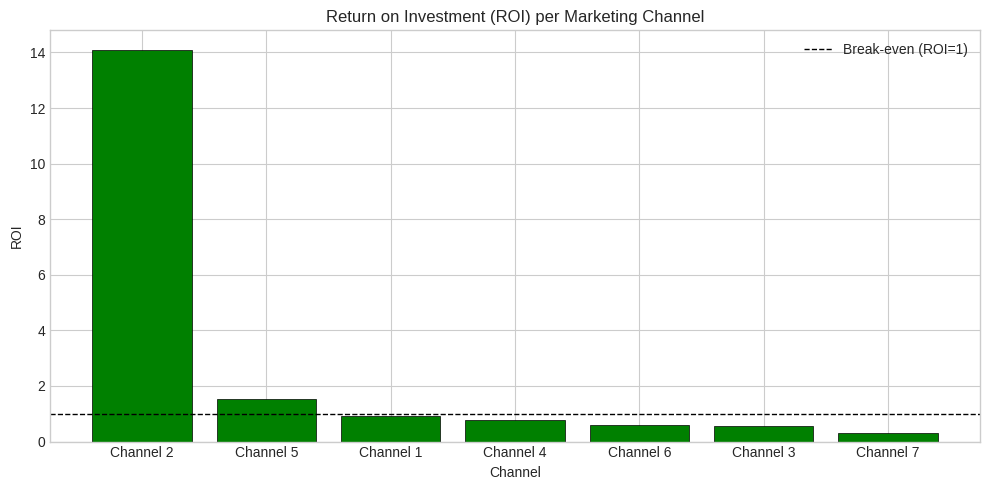

In [21]:
plt.figure(figsize=(10, 5))
colors = ['green' if r > 0 else 'red' for r in roi_df['roi']]
plt.bar(roi_df['channel'], roi_df['roi'], color=colors, edgecolor='black', linewidth=0.5)
plt.axhline(y=1, color='black', linestyle='--', linewidth=1, label='Break-even (ROI=1)')
plt.title('Return on Investment (ROI) per Marketing Channel')
plt.xlabel('Channel')
plt.ylabel('ROI')
plt.legend()
plt.tight_layout()
plt.show()

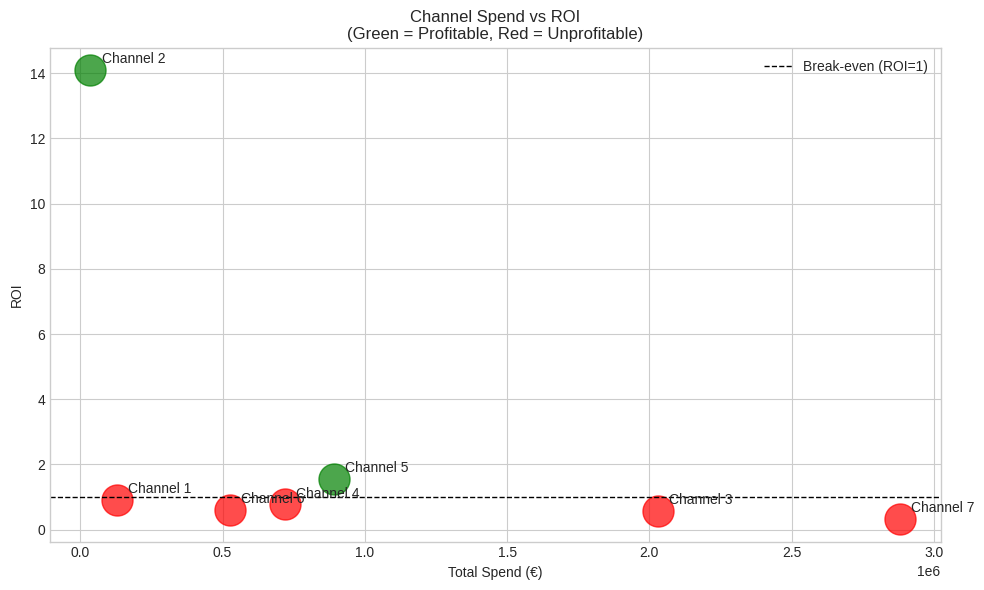

In [22]:
plt.figure(figsize=(10, 6))
for _, row in roi_df.iterrows():
    plt.scatter(row['total_spend'], row['roi'], 
                s=500, alpha=0.7,
                color='green' if row['roi'] > 1 else 'red')
    plt.annotate(row['channel'], 
                 (row['total_spend'], row['roi']),
                 textcoords='offset points',
                 xytext=(8, 5), fontsize=10)

plt.axhline(y=1, color='black', linestyle='--', linewidth=1, label='Break-even (ROI=1)')
plt.title('Channel Spend vs ROI\n(Green = Profitable, Red = Unprofitable)')
plt.xlabel('Total Spend (€)')
plt.ylabel('ROI')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Key Findings & Recommendations

### Model Performance
- MAPE: 19.66% — acceptable for MMM
- R²: 0.446 — model explains 44.6% of revenue variance
- All R-hat values = 1.00 — perfect convergence

### Channel Performance
| Channel | Total Spend | ROI | Verdict |
|---------|------------|-----|---------|
| Channel 2 | €35,739 | 14.05 | 🟢 Massively underinvested |
| Channel 5 | €891,864 | 1.53 | 🟢 Profitable |
| Channel 1 | €129,543 | 0.89 | 🔴 Slightly below break-even |
| Channel 4 | €719,174 | 0.79 | 🔴 Unprofitable |
| Channel 6 | €526,625 | 0.59 | 🔴 Unprofitable |
| Channel 3 | €2,028,747 | 0.57 | 🔴 High spend, poor return |
| Channel 7 | €2,880,942 | 0.32 | 🔴 Worst ROI, highest spend |

### Recommendations
1. **Increase Channel 2 budget significantly** — highest ROI by far
2. **Maintain or grow Channel 5** — only other profitable channel
3. **Reduce Channel 7 spend** — biggest budget, worst returns
4. **Investigate Channel 3** — second highest spend, poor ROI


## 9. What I Would Do With More Time
- Run 4 chains for more robust convergence diagnostics
- Model saturation effects (diminishing returns on high spend)
- Add holiday/promotion flags as external regressors
- Use hierarchical priors to share information across channels
- Cross-validate on held-out weeks to test generalization
- Experiment with JAX backend for faster sampling

## Glossary

| Term | Full Form | Definition |
|------|-----------|------------|
| MMM | Marketing Mix Model | Statistical model that quantifies the contribution of each marketing channel to revenue |
| Bayesian | — | Statistical approach that expresses results as probability distributions rather than single point estimates |
| MCMC | Markov Chain Monte Carlo | Algorithm used to sample from the posterior distribution |
| NUTS | No U-Turn Sampler | The specific MCMC algorithm PyMC uses — automatically tunes itself |
| Adstock | Advertising Stock | Transformation that captures the delayed carry-over effect of advertising spend |
| Decay Rate | — | How quickly the adstock effect fades — 0 means no carry-over, 1 means infinite memory |
| Prior | — | Our belief about a parameter before seeing the data |
| Posterior | — | Updated belief about a parameter after the model has seen the data |
| R-hat | Potential Scale Reduction Factor | Convergence diagnostic — value of 1.00 means chains agree perfectly |
| ESS | Effective Sample Size | How many independent samples the chains are equivalent to — higher is better |
| MAPE | Mean Absolute Percentage Error | Average % difference between predicted and actual values |
| MAE | Mean Absolute Error | Average absolute difference between predicted and actual values in euros |
| R² | R-Squared | Proportion of revenue variance explained by the model — 1.0 is perfect |
| ROI | Return on Investment | Revenue generated per euro spent on a channel |
| Fourier Terms | — | Sine/cosine waves used to capture repeating seasonal patterns |